In [1]:
# beacon_optimisation.ipynb
# Member A: Beacon placement optimisation using GDOP analysis (A3)

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

np.random.seed(42)

# ── Track geometry (from track_model.ipynb) ──────────────
d   = 100.0
rho = 20.0
L   = 2*d + 2*np.pi*rho

def s_to_xy(s):
    """Arc-length s -> Cartesian (x, y) on centreline."""
    s = s % L
    if s < d:
        return np.array([s, rho])
    elif s < d + np.pi*rho:
        theta = (s - d) / rho
        return np.array([d + rho*np.sin(theta), rho*np.cos(theta)])
    elif s < 2*d + np.pi*rho:
        return np.array([2*d + np.pi*rho - s, -rho])
    else:
        theta = (s - (2*d + np.pi*rho)) / rho
        return np.array([-rho*np.sin(theta), -rho*np.cos(theta)])
        

In [2]:
# ── GDOP calculation ─────────────────────────────────────
# GDOP (Geometric Dilution of Precision) measures how beacon
# geometry affects positioning accuracy.
# Lower GDOP = better positioning accuracy.
#
# For a set of beacons at positions b_i, given vehicle at position p:
#   H = Jacobian of measurement function w.r.t. position
#   GDOP = sqrt(trace((H^T H)^{-1}))

def compute_gdop(vehicle_pos, beacons):
    """
    Compute GDOP at a given vehicle position for a set of beacons.
    vehicle_pos: (2,) array, (x, y)
    beacons: (n, 2) array of beacon positions
    Returns GDOP value (lower is better).
    """
    H = []
    for b in beacons:
        diff = vehicle_pos - b
        dist = np.linalg.norm(diff)
        if dist < 1e-6:
            return np.inf
        H.append(diff / dist)
    H = np.array(H)   # shape (n, 2)

    try:
        HtH_inv = np.linalg.inv(H.T @ H)
        gdop = np.sqrt(np.trace(HtH_inv))
    except np.linalg.LinAlgError:
        gdop = np.inf

    return gdop
    

In [3]:
# ── Sample vehicle positions along the track ─────────────
# Take 200 points evenly spaced around the track
n_track_pts = 200
s_samples = np.linspace(0, L, n_track_pts, endpoint=False)
track_pts  = np.array([s_to_xy(s) for s in s_samples])

def mean_gdop(beacons):
    """
    Compute mean GDOP over all sampled track positions.
    Lower = better beacon placement.
    """
    gdops = [compute_gdop(p, beacons) for p in track_pts]
    gdops = [g for g in gdops if np.isfinite(g)]
    return np.mean(gdops) if gdops else np.inf

# Quick test with 3 arbitrary beacons
test_beacons = np.array([
    [ 50.0,  50.0],
    [120.0, -50.0],
    [-30.0,   0.0]
])
print(f"Test beacons mean GDOP: {mean_gdop(test_beacons):.4f}")

Test beacons mean GDOP: 1.3349


In [4]:
# ── Define candidate beacon positions ────────────────────
def is_outside_track(point, margin=5.0):
    """Returns True if point is outside the track lane."""
    px, py = point
    # Quick check: compute distance to centreline
    dists = np.linalg.norm(track_pts - point, axis=1)
    min_dist = np.min(dists)
    return min_dist > (2.0 + margin)

# Coarse grid search
x_candidates = np.linspace(-60, 160, 12)
y_candidates = np.linspace(-60,  60, 12)

candidates = []
for x in x_candidates:
    for y in y_candidates:
        pt = np.array([x, y])
        if is_outside_track(pt):
            candidates.append(pt)

candidates = np.array(candidates)
total = len(list(combinations(range(len(candidates)), 3)))
print(f"Candidates: {len(candidates)}, Combinations: {total}")

Candidates: 124, Combinations: 310124


In [7]:
# ── Search for optimal 3-beacon combination ──────────────
best_gdop = np.inf
best_beacons = None
count = 0

for combo in combinations(range(len(candidates)), 3):
    b = candidates[list(combo)]
    g = mean_gdop(b)
    if g < best_gdop:
        best_gdop = g
        best_beacons = b.copy()
    count += 1
    if count % 50000 == 0:
        print(f"  {count}/310124 checked, best GDOP: {best_gdop:.4f}")

print(f"\nDone. Best mean GDOP: {best_gdop:.4f}")
print(f"Best beacon positions:")
for i, b in enumerate(best_beacons):
    print(f"  Beacon {i+1}: ({b[0]:.1f}, {b[1]:.1f})")
print(f"\nOriginal hand-picked GDOP: {mean_gdop(test_beacons):.4f}")
print(f"Optimised GDOP:            {best_gdop:.4f}")

  50000/310124 checked, best GDOP: 1.2045
  100000/310124 checked, best GDOP: 1.2028


/var/folders/98/_d9w09b52kxfysjykc_xyhmm0000gn/T/ipykernel_62614/1193758001.py:28: RuntimeWarning: invalid value encountered in sqrt
  gdop = np.sqrt(np.trace(HtH_inv))


  150000/310124 checked, best GDOP: 1.2028
  200000/310124 checked, best GDOP: 1.1954
  250000/310124 checked, best GDOP: 1.1954
  300000/310124 checked, best GDOP: 1.1954

Done. Best mean GDOP: 1.1954
Best beacon positions:
  Beacon 1: (-20.0, -60.0)
  Beacon 2: (40.0, 27.3)
  Beacon 3: (100.0, -60.0)

Original hand-picked GDOP: 1.3349
Optimised GDOP:            1.1954


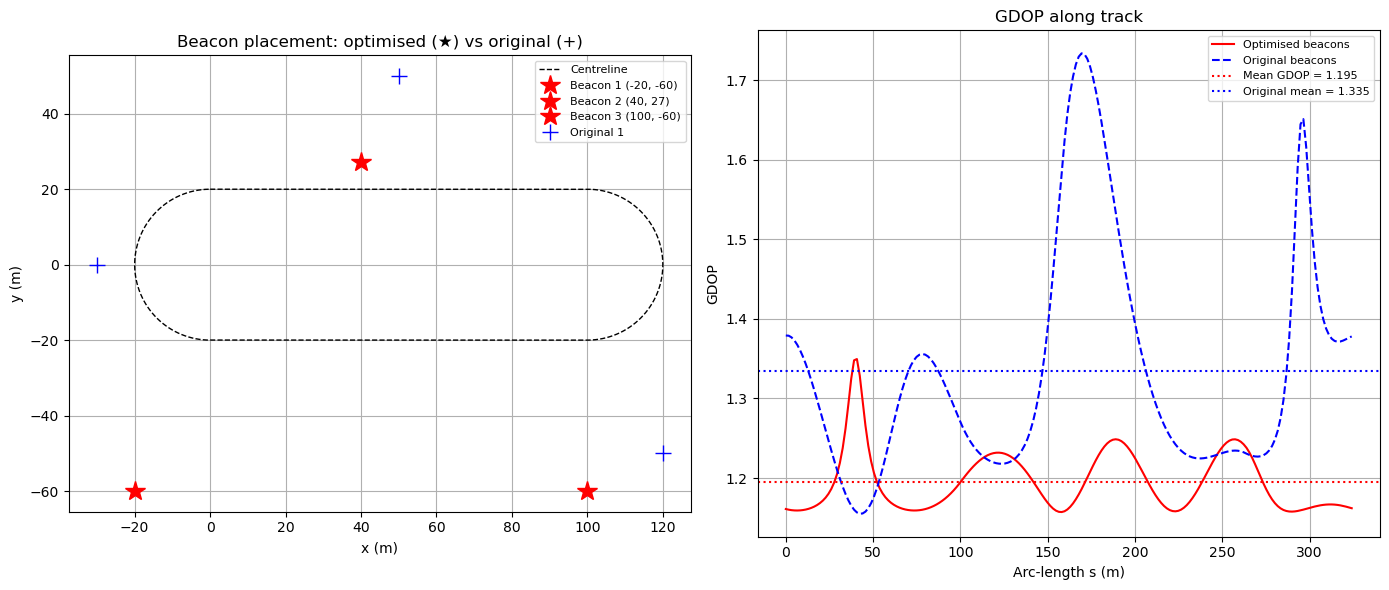


Final beacon positions (use these in EKF code):
beacons = np.array([
    [-20.0, -60.0],
    [40.0, 27.3],
    [100.0, -60.0],
])


In [9]:
# ── Visualise optimised beacon placement ─────────────────
s_vals = np.linspace(0, L, 1000)
centre = np.array([s_to_xy(s) for s in s_vals])

# Compute GDOP at every track point for optimised beacons
gdop_vals = np.array([compute_gdop(p, best_beacons) for p in track_pts])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: track + beacon positions
axes[0].plot(centre[:,0], centre[:,1], 'k--', lw=1, label='Centreline')
for i, b in enumerate(best_beacons):
    axes[0].plot(b[0], b[1], 'r*', markersize=15, label=f'Beacon {i+1} ({b[0]:.0f}, {b[1]:.0f})')
for i, b in enumerate(test_beacons):
    axes[0].plot(b[0], b[1], 'b+', markersize=12, label=f'Original {i+1}' if i==0 else None)
axes[0].set_aspect('equal')
axes[0].grid(True)
axes[0].legend(fontsize=8)
axes[0].set_xlabel('x (m)')
axes[0].set_ylabel('y (m)')
axes[0].set_title('Beacon placement: optimised (★) vs original (+)')

# Right: GDOP along track
axes[1].plot(s_samples, gdop_vals, 'r-', label='Optimised beacons')
gdop_orig = np.array([compute_gdop(p, test_beacons) for p in track_pts])
axes[1].plot(s_samples, gdop_orig, 'b--', label='Original beacons')
axes[1].axhline(np.mean(gdop_vals), color='r', linestyle=':', label=f'Mean GDOP = {np.mean(gdop_vals):.3f}')
axes[1].axhline(np.mean(gdop_orig), color='b', linestyle=':', label=f'Original mean = {np.mean(gdop_orig):.3f}')
axes[1].set_xlabel('Arc-length s (m)')
axes[1].set_ylabel('GDOP')
axes[1].set_title('GDOP along track')
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.savefig('figures/beacon_gdop.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal beacon positions (use these in EKF code):")
print(f"beacons = np.array([")
for b in best_beacons:
    print(f"    [{b[0]:.1f}, {b[1]:.1f}],")
print(f"])")

In [10]:
# ── Summary ──────────────────────────────────────────────
print("=" * 50)
print("A3 BEACON OPTIMISATION RESULTS")
print("=" * 50)
print(f"\nMethod: GDOP minimisation over {len(candidates)} candidate positions")
print(f"Number of beacons: 3 (minimum for 2D localisation)")
print(f"\nOptimised mean GDOP: {best_gdop:.4f}")
print(f"Original mean GDOP:  {mean_gdop(test_beacons):.4f}")
print(f"Improvement:         {(mean_gdop(test_beacons) - best_gdop) / mean_gdop(test_beacons) * 100:.1f}%")
print(f"\nFinal beacon coordinates (update in EKF code):")
print(f"beacons = np.array([")
for i, b in enumerate(best_beacons):
    print(f"    [{b[0]:.1f}, {b[1]:.1f}],   # Beacon {i+1}")
print(f"])")

A3 BEACON OPTIMISATION RESULTS

Method: GDOP minimisation over 124 candidate positions
Number of beacons: 3 (minimum for 2D localisation)

Optimised mean GDOP: 1.1954
Original mean GDOP:  1.3349
Improvement:         10.5%

Final beacon coordinates (update in EKF code):
beacons = np.array([
    [-20.0, -60.0],   # Beacon 1
    [40.0, 27.3],   # Beacon 2
    [100.0, -60.0],   # Beacon 3
])


In [12]:
# ── 4-beacon search with reduced candidates ──────────────
# Use coarser grid for 4-beacon search
x_cand2 = np.linspace(-60, 160, 8)
y_cand2 = np.linspace(-60,  60, 8)

cand2 = []
for x in x_cand2:
    for y in y_cand2:
        pt = np.array([x, y])
        if is_outside_track(pt):
            cand2.append(pt)

cand2 = np.array(cand2)
total_4 = len(list(combinations(range(len(cand2)), 4)))
print(f"Reduced candidates: {len(cand2)}, Combinations: {total_4}")

Reduced candidates: 56, Combinations: 367290


In [13]:
x_cand3 = np.linspace(-60, 160, 6)
y_cand3 = np.linspace(-60,  60, 6)

cand3 = []
for x in x_cand3:
    for y in y_cand3:
        pt = np.array([x, y])
        if is_outside_track(pt):
            cand3.append(pt)

cand3 = np.array(cand3)
total_4 = len(list(combinations(range(len(cand3)), 4)))
print(f"Candidates: {len(cand3)}, Combinations: {total_4}")

Candidates: 32, Combinations: 35960


In [14]:
# ── 4-beacon exhaustive search ───────────────────────────
best_gdop_4 = np.inf
best_beacons_4 = None
count = 0

for combo in combinations(range(len(cand3)), 4):
    b = cand3[list(combo)]
    g = mean_gdop(b)
    if g < best_gdop_4:
        best_gdop_4 = g
        best_beacons_4 = b.copy()
    count += 1

print(f"Best 3-beacon GDOP: {best_gdop:.4f}")
print(f"Best 4-beacon GDOP: {best_gdop_4:.4f}")
print(f"Improvement from 3→4: {(best_gdop - best_gdop_4) / best_gdop * 100:.1f}%")
print(f"\n4-beacon positions:")
for i, b in enumerate(best_beacons_4):
    print(f"  Beacon {i+1}: ({b[0]:.1f}, {b[1]:.1f})")
print(f"\nConclusion: {'4 beacons justified' if (best_gdop - best_gdop_4)/best_gdop > 0.05 else '3 beacons sufficient (improvement < 5%)'}")

Best 3-beacon GDOP: 1.1954
Best 4-beacon GDOP: 1.0133
Improvement from 3→4: 15.2%

4-beacon positions:
  Beacon 1: (28.0, -60.0)
  Beacon 2: (28.0, 60.0)
  Beacon 3: (160.0, -60.0)
  Beacon 4: (160.0, 60.0)

Conclusion: 4 beacons justified


In [15]:
# ── 4-beacon fine search (same grid as 3-beacon) ─────────
total_4_fine = len(list(combinations(range(len(candidates)), 4)))
print(f"Fine grid candidates: {len(candidates)}, Combinations: {total_4_fine}")
print("Estimated time: ~10-20 minutes")

Fine grid candidates: 124, Combinations: 9381251
Estimated time: ~10-20 minutes


In [16]:
# ── 4-beacon fine grid exhaustive search ─────────────────
best_gdop_4_fine = np.inf
best_beacons_4_fine = None
count = 0
total = 9381251

for combo in combinations(range(len(candidates)), 4):
    b = candidates[list(combo)]
    g = mean_gdop(b)
    if g < best_gdop_4_fine:
        best_gdop_4_fine = g
        best_beacons_4_fine = b.copy()
    count += 1
    if count % 1000000 == 0:
        print(f"  {count}/{total} checked, best GDOP: {best_gdop_4_fine:.4f}")

print(f"\nDone.")
print(f"Best 3-beacon GDOP: {best_gdop:.4f}")
print(f"Best 4-beacon GDOP: {best_gdop_4_fine:.4f}")
print(f"Improvement from 3→4: {(best_gdop - best_gdop_4_fine) / best_gdop * 100:.1f}%")
print(f"\n4-beacon positions:")
for i, b in enumerate(best_beacons_4_fine):
    print(f"  Beacon {i+1}: ({b[0]:.1f}, {b[1]:.1f})")

KeyboardInterrupt: 